Лабораторная работа 5 Интерпритация и анализ важности признаков

Цель: Научиться объяснять результаты работы модели

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv("finish_laba3.csv")

In [10]:
X = df.drop(columns=['arr_delay'])
y = df['arr_delay']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(10)

,Feature,Importance
17,total_delay,9.998363e-01
14,security_delay,1.278571e-04
7,security_ct,1.646567e-05
3,arr_del15,2.989688e-06
16,delay_per_flight,2.578692e-06
54,airport_ANC,1.857457e-06
195,airport_HIB,9.930333e-07
6,nas_ct,9.064193e-07
4,carrier_ct,6.227513e-07
11,carrier_delay,5.775139e-07


Определение важности признаков

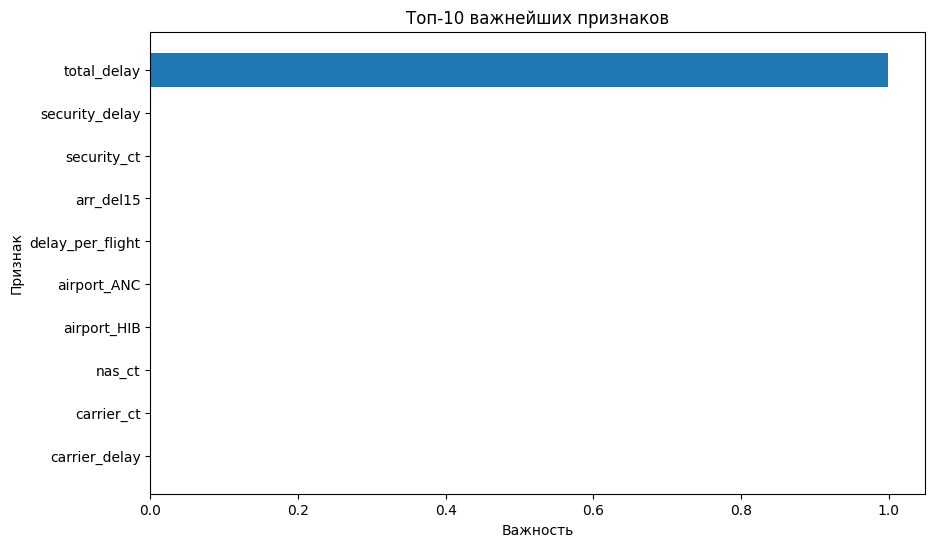

In [12]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Топ-10 важнейших признаков")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

Визуализация важности признаков

In [13]:
top_features

,Feature,Importance
17,total_delay,9.998363e-01
14,security_delay,1.278571e-04
7,security_ct,1.646567e-05
3,arr_del15,2.989688e-06
16,delay_per_flight,2.578692e-06
54,airport_ANC,1.857457e-06
195,airport_HIB,9.930333e-07
6,nas_ct,9.064193e-07
4,carrier_ct,6.227513e-07
11,carrier_delay,5.775139e-07


Анализ влияния признаков

In [14]:
y_pred = model.predict(X_test)

errors = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": y_test - y_pred
})

errors.head()

,Actual,Predicted,Error
87503,212.0,212.00,0.00
31405,273.0,273.00,0.00
75126,161.0,161.00,0.00
53310,1443.0,1442.99,0.01
27888,162.0,162.00,0.00


Анализ ошибок модели

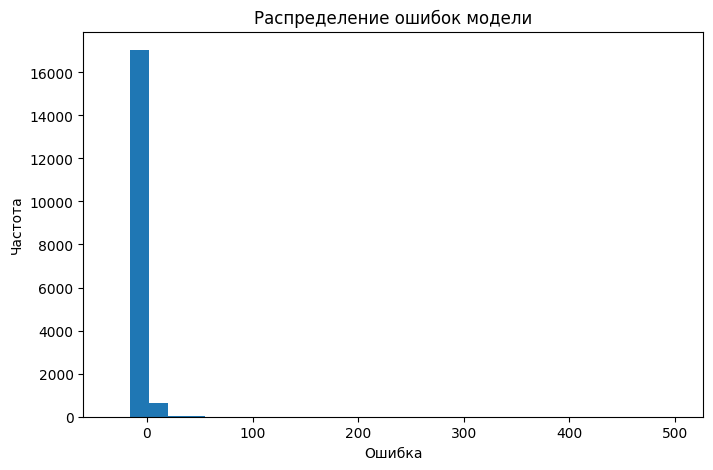

In [15]:
plt.figure(figsize=(8,5))
plt.hist(errors["Error"], bins=30)
plt.title("Распределение ошибок модели")
plt.xlabel("Ошибка")
plt.ylabel("Частота")
plt.show()

Визуализация ошибок

In [16]:
errors.sort_values(by="Error", key=abs, ascending=False).head(10)

,Actual,Predicted,Error
19545,5061.0,4560.70,500.30
26593,811.0,462.41,348.59
36673,2432.0,2151.24,280.76
18416,5652.0,5394.20,257.80
15496,1159.0,916.39,242.61
15083,2962.0,2723.34,238.66
1219,4746.0,4523.55,222.45
18258,1839.0,1624.05,214.95
23243,3319.0,3112.56,206.44
79487,2918.0,2719.98,198.02


Анализ отдельных примеров

Вывод:
Определена важность признаков модели
Построена визуализация влияния факторов
Проанализированы ошибки предсказаний
Выявлены слабые и сильные стороны модели

In [17]:
df.to_csv("finish_laba5.csv", index=False)